In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("bookscraper/books.csv")
df.head()

,Title,Category,Price,Rating,Availability,Description,UPC,Number of Reviews,Product URL
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (100, 9)


In [6]:
total_records = len(df)

missing_values = df.isnull().sum().sum()

duplicate_upc = df["UPC"].duplicated().sum()

print("Total Scraped Records :", total_records)
print("Total Missing Values  :", missing_values)
print("Duplicate UPC Values  :", duplicate_upc)

Total Scraped Records : 100
Total Missing Values  : 0
Duplicate UPC Values  : 0


## Now the Data Preprocessing part 
which includes cleaning up extra spaces,improving the inconsistent text,removing duplicate books by UPC and handling missing descriptions.

In [58]:
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

print("Extra spaces removed successfully.")

Extra spaces removed successfully.


In [68]:
df["Category"] = df["Category"].str.title()
df["Availability"] = df["Availability"].str.strip()

print("Text formatting standardized.")

Text formatting standardized.


In [ ]:
before = len(df)
df = df.drop_duplicates(subset="UPC")
after = len(df)

print("Records before removing duplicates:", before)
print("Records after removing duplicates :", after)
print("Duplicate books removed:", before - after)

Records before removing duplicates: 100
Records after removing duplicates : 100
Duplicate books removed: 0


In [ ]:

df["Description"] = df["Description"].fillna("No Description Available")
print("Missing descriptions handled.")

Missing descriptions handled.


Now converting to numeric value, map rating One-Five to integers, and extracting available stock count

In [ ]:
df["Price"] = df["Price"].str.replace("£", "", regex=False)
df["Price"] = df["Price"].astype(float)
df["Price"].head()

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
Name: Price, dtype: float64

In [ ]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}
df["Rating"] = df["Rating"].map(rating_map)
df["Rating"].head()

0    2
1    2
2    1
3    1
4    3
Name: Rating, dtype: int64

In [ ]:
df["Stock Count"] = (
    df["Availability"]
    .str.extract(r"\((\d+) available\)")
    .fillna(0)
    .astype(int)
)
df[["Availability", "Stock Count"]].head()

,Availability,Stock Count
0,In stock (19 available) In stock In stock In s...,19
1,In stock (19 available) In stock In stock In s...,19
2,In stock (19 available) In stock In stock In s...,19
3,In stock (19 available) In stock In stock In s...,19
4,In stock (19 available) In stock In stock In s...,19


saving the updated dataset

In [ ]:
df.to_csv("bookscraper/books_cleaned.csv", index=False)

Adding three useful features 

In [ ]:
vowels = ("A", "E", "I", "O", "U")
df["starts_with_vowel"] = df["Title"].str.upper().str.startswith(vowels)
df[["Title", "starts_with_vowel"]].head()

,Title,starts_with_vowel
0,It's Only the Himalayas,True
1,Libertarianism for Beginners,False
2,Mesaerion: The Best Science Fiction Stories 18...,False
3,Olio,True
4,Our Band Could Be Your Life: Scenes from the A...,True


In [ ]:
#book whose stock is higher than 18
df["high_stock"] = df["Stock Count"] > 18
df[["Stock Count", "high_stock"]].head(10)

,Stock Count,high_stock
0,19,True
1,19,True
2,19,True
3,19,True
4,19,True
5,19,True
6,19,True
7,19,True
8,19,True
9,19,True


In [ ]:
#to know which books have stock higher than 18
df[df["high_stock"]][["Title", "Stock Count"]].head(10)

,Title,Stock Count
0,It's Only the Himalayas,19
1,Libertarianism for Beginners,19
2,Mesaerion: The Best Science Fiction Stories 18...,19
3,Olio,19
4,Our Band Could Be Your Life: Scenes from the A...,19
5,Rip it Up and Start Again,19
6,Scott Pilgrim's Precious Little Life (Scott Pi...,19
7,Set Me Free,19
8,Shakespeare's Sonnets,19
9,"Starving Hearts (Triangular Trade Trilogy, #1)",19


In [ ]:
#checking which books have price higher than average and have rating is 4 0r 5
average_price = df["Price"].mean()

df["premium_book"] = (
    (df["Price"] > average_price) &
    (df["Rating"] >= 4)
)

df[["Price", "Rating", "premium_book"]].head()

,Price,Rating,premium_book
0,45.17,2,False
1,51.33,2,False
2,37.59,1,False
3,23.88,1,False
4,57.25,3,False


Visualizing 

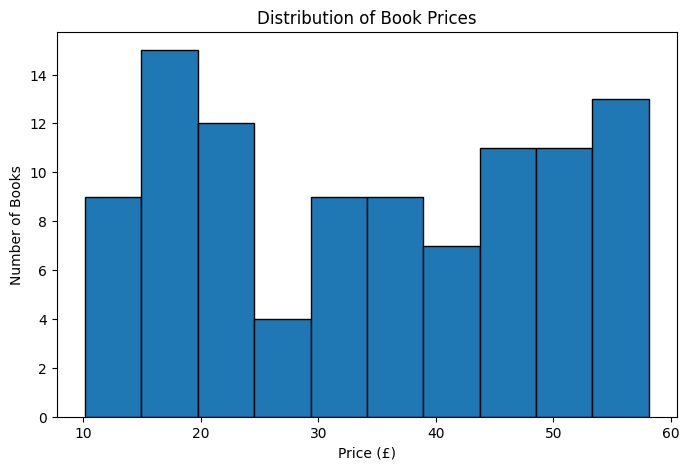

In [ ]:
#I have first taken proce distribution
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=10, edgecolor="black")
plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

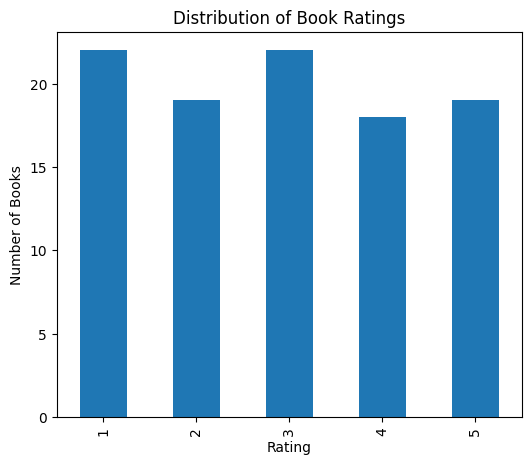

In [ ]:
#ratind distribution
plt.figure(figsize=(6,5))
df["Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

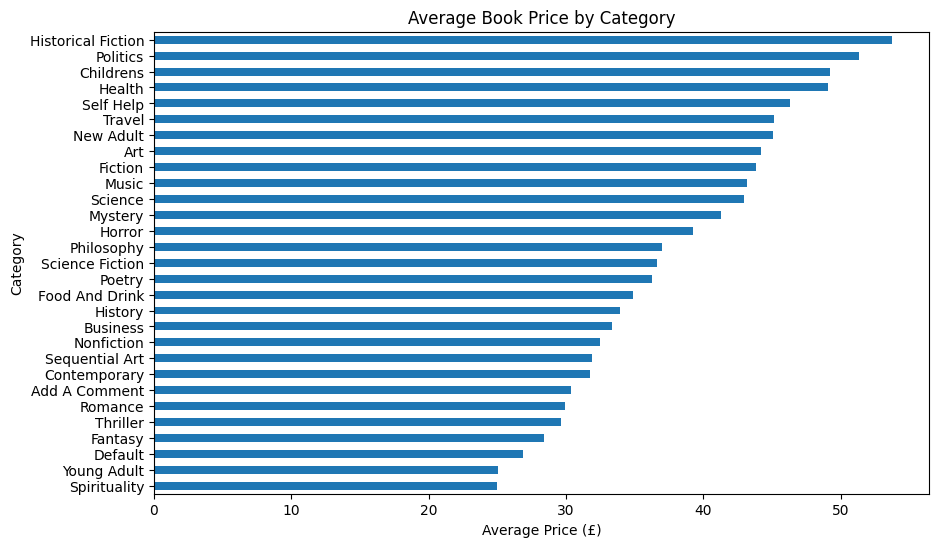

In [ ]:
#average price by category
avg_price = df.groupby("Category")["Price"].mean().sort_values()
plt.figure(figsize=(10,6))
avg_price.plot(kind="barh")
plt.title("Average Book Price by Category")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")

plt.show()

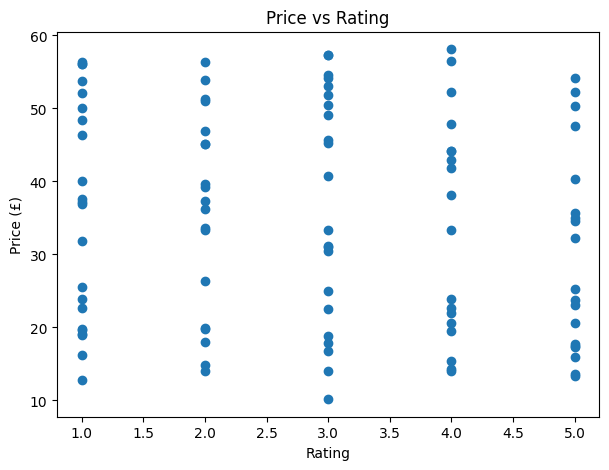

In [ ]:
#price aganst rating
plt.figure(figsize=(7,5))
plt.scatter(df["Rating"], df["Price"])
plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.show()

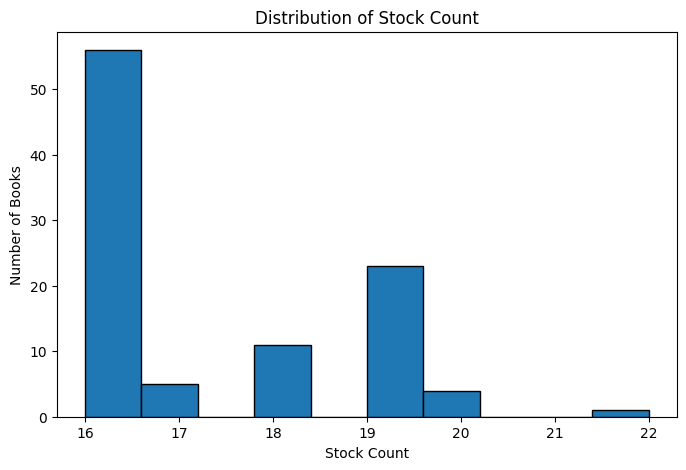

In [ ]:
#stock count distribution
plt.figure(figsize=(8,5))
plt.hist(df["Stock Count"], bins=10, edgecolor="black")
plt.title("Distribution of Stock Count")
plt.xlabel("Stock Count")
plt.ylabel("Number of Books")

plt.show()

from the combined book descriptions generating a word cloud.

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

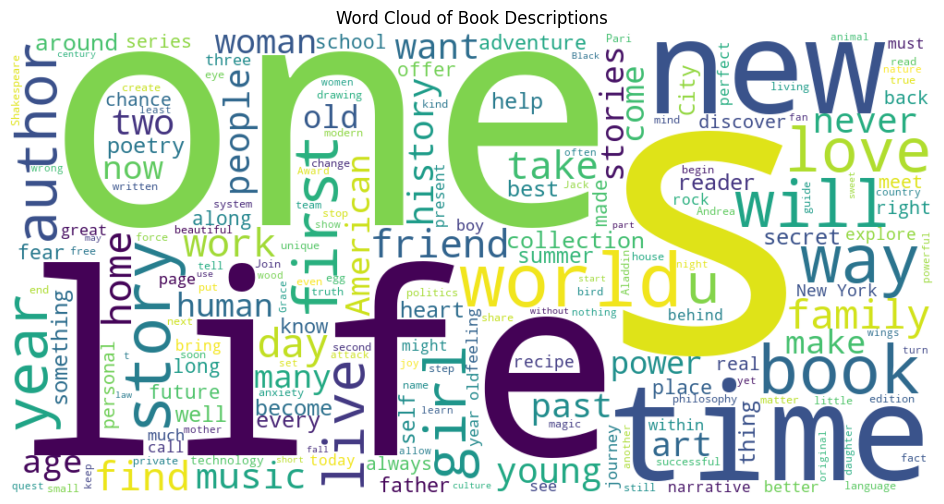

In [ ]:
# first need to combine all book descriptions into one text
text = " ".join(df["Description"].fillna("").astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=STOPWORDS,
    colormap="viridis"
).generate(text)
#display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")

plt.savefig("wordcloud_books.png", dpi=300, bbox_inches="tight")

plt.show()

In [60]:
# Summary statistics
summary = df[["Price", "Rating", "Stock Count"]].describe()
summary

,Price,Rating,Stock Count
count,100.000000,100.000000,100.000000
mean,34.560700,2.930000,17.180000
std,14.638531,1.423149,1.479694
min,10.160000,1.000000,16.000000
25%,19.897500,2.000000,16.000000
50%,34.775000,3.000000,16.000000
75%,47.967500,4.000000,19.000000
max,58.110000,5.000000,22.000000


In [ ]:
#counting category
df["Category"].value_counts()

Category
Sequential Art        14
Nonfiction            12
Default                9
Poetry                 7
Fiction                5
Add A Comment          5
Food And Drink         5
Fantasy                4
Young Adult            4
History                4
Childrens              3
Mystery                3
Thriller               3
Music                  3
Philosophy             2
Spirituality           2
Romance                2
Science Fiction        2
New Adult              1
Self Help              1
Health                 1
Science                1
Horror                 1
Travel                 1
Contemporary           1
Art                    1
Politics               1
Business               1
Historical Fiction     1
Name: count, dtype: int64

In [64]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
Sequential Art        14
Nonfiction            12
Default                9
Poetry                 7
Fiction                5
Add A Comment          5
Food And Drink         5
Fantasy                4
Young Adult            4
History                4
Childrens              3
Mystery                3
Thriller               3
Music                  3
Philosophy             2
Spirituality           2
Romance                2
Science Fiction        2
New Adult              1
Self Help              1
Health                 1
Science                1
Horror                 1
Travel                 1
Contemporary           1
Art                    1
Politics               1
Business               1
Historical Fiction     1
Name: count, dtype: int64


In [ ]:
#Highly Rated Books
highly_rated = df[df["Rating"] == 5]

highly_rated[["Title", "Category", "Price", "Rating"]].head(10)

,Title,Category,Price,Rating
5,Rip it Up and Start Again,Music,35.02,5
6,Scott Pilgrim's Precious Little Life (Scott Pi...,Sequential Art,52.29,5
7,Set Me Free,Young Adult,17.46,5
15,Sapiens: A Brief History of Humankind,History,54.23,5
21,Sophie's World,Philosophy,15.94,5
23,The Elephant Tree,Thriller,23.82,5
25,The Four Agreements: A Practical Guide to Pers...,Spirituality,17.66,5
27,Worlds Elsewhere: Journeys Around Shakespeare’...,Nonfiction,40.30,5
31,Black Dust,Romance,34.53,5
37,Thirst,Fiction,17.27,5


In [66]:
#stock pattern- books with high pattern 
high_stock = df[df["Stock Count"] > 18]
high_stock[["Title", "Stock Count"]].head(10)

,Title,Stock Count
0,It's Only the Himalayas,19
1,Libertarianism for Beginners,19
2,Mesaerion: The Best Science Fiction Stories 18...,19
3,Olio,19
4,Our Band Could Be Your Life: Scenes from the A...,19
5,Rip it Up and Start Again,19
6,Scott Pilgrim's Precious Little Life (Scott Pi...,19
7,Set Me Free,19
8,Shakespeare's Sonnets,19
9,"Starving Hearts (Triangular Trade Trilogy, #1)",19


Task-3 point-3:
-Here basically the price pattern from the summary statistics shows that the ranges of the books vary considerably. According to what shown in histogram most books fall within a moderate price range.
-For the rating pattern the rating distribuition indicates that the ratings 3,4,5 are more commonly given ratings.
- the category pattern shows that there are books which are comparatively more than the others.


Task -4
-Here the there were no such duplicate books neither were UPCs.As per the numbers of the ouptut
-Ratings 3,4 and 5 are like more frequent ones.
-There are categories which have higher prices compared to other, as per the plot.
-Most books are priced mostly within moderate price range.
-Word Cloud used mostly highlights the frequently used words in book descriptions.
-Also the dataset contains books from multiple categories with uneven distribuition.
-The missing descriptions were handled during preprocessing and not any such missing were found.
-Stock availability is moderate, while there are few who have high stock counts.


The anaylsis for price and rating suggests book price is not a reliable indicator of its rating, as highly rated books are available at different price levels.

Some categories contain a larger number of books, while others have higher average prices, indicating differences in both popularity and pricing.

The books with higher ratings and comparatively lower prices are to be considered for best value books.


For limitations, first of all it only includes first few pages of the website. Also it does not include all the information provided of the book.